In [45]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

def select_candidates(uids, fractions, n_models, alpha=0.05):
    """
    Description:
        Run BH-FDR-corrected one-sided binomial test against the median
        baseline, returning significant uids and the lowest passing fraction.

    Args:
        uids: List of identifiers, one per entry.
        fractions: List of observed proportions (e.g. NAC fractions).
        n_models: List of sample sizes (per entry).
        alpha: FDR level.

    Returns:
        Tuple (set of significant uids, lowest significant fraction or None).
    """
    baseline = np.median(fractions)
    pvals = [binomtest(int(f * n), n, p=baseline, alternative='greater').pvalue
             for f, n in zip(fractions, n_models)]
    rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    candidates = {uids[i] for i in range(len(uids)) if rejected[i]}
    sig_fracs = [fractions[i] for i in range(len(uids)) if rejected[i]]
    threshold = min(sig_fracs) if sig_fracs else None
    return candidates, threshold


In [46]:
import pandas as pd


result_path = './results/carA_homologs_nac_result_2C.csv'


df = pd.read_csv(result_path)
df_conf = df[(df['n_confident_holo'] >= 30) & (df['n_confident_apo'] >= 30)]

df_conf

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A010YLP6,0.354167,1;3;4;5;8;10;11;13;14;16;18;30;32;35;39;40;41,48,2.598909,1.171320,0.32,3;4;5;7;8;10;12;16;18;19;27;31;45;46;49;50;55;...,100
3,A0A024JZE3,0.022222,20,45,2.392342,1.199905,0.22,8;11;15;27;34;36;44;51;56;59;61;63;67;68;73;82...,100
4,A0A024JZE8,0.066667,1;28;41,45,2.637136,1.484345,0.16,5;8;10;21;54;57;59;63;64;70;83;84;86;88;90;96,100
5,A0A045K2P5,0.076923,6;18;20;28,52,2.298625,1.193063,0.03,7;17;47,100
6,A0A051U3G5,0.064516,2;22,31,2.989460,1.123785,0.07,4;69;77;80;82;88;91,100
...,...,...,...,...,...,...,...,...,...
664,W7J139,0.309091,4;6;9;10;11;12;16;17;18;26;32;34;35;38;39;47;52,55,2.245017,1.304602,0.66,1;2;4;5;7;8;10;11;12;13;15;17;18;19;20;23;24;2...,100
667,W9B0J1,0.070175,11;14;19;32,57,2.140178,1.256572,0.01,22,100
668,X0Q040,0.040000,11;29,50,2.378274,1.232604,0.00,NaN,100
669,X8A9W7,0.037736,48;49,53,2.305766,1.263219,0.17,5;21;26;41;49;54;61;62;63;69;70;76;79;90;92;95...,100


In [47]:

entris = df_conf['entry'].tolist()

nac_fraction_holo = df_conf['nac_fraction_holo'].tolist()
nac_fraction_apo = df_conf['nac_fraction_apo'].tolist()

n_conf_models_holo = df_conf['n_confident_holo'].tolist()
n_conf_models_apo = df_conf['n_confident_apo'].tolist()

sig_holo, thr_holo = select_candidates(entris, nac_fraction_holo, n_conf_models_holo)
sig_apo,  thr_apo  = select_candidates(entris, nac_fraction_apo,  n_conf_models_apo)
both = sig_holo & sig_apo

print(f"Holo:  {len(sig_holo):>3d} / {len(entris)}  (threshold: {thr_holo:.1%})")
print(f"Apo:   {len(sig_apo):>3d} / {len(entris)}  (threshold: {thr_apo:.1%})")
print(f"Both:  {len(both):>3d}")

Holo:   69 / 426  (threshold: 21.6%)
Apo:   185 / 426  (threshold: 35.0%)
Both:   63


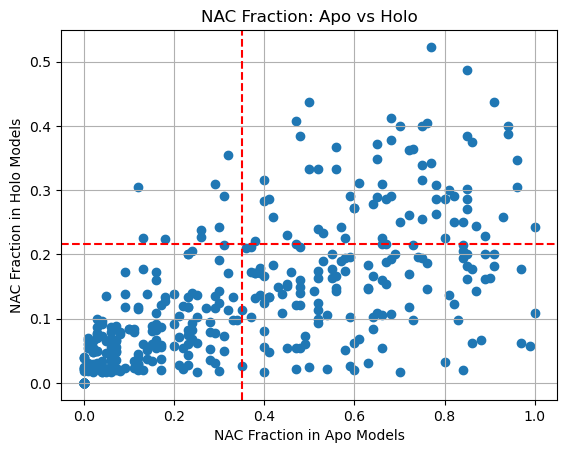

In [48]:
import matplotlib.pyplot as plt

plt.scatter(nac_fraction_apo, nac_fraction_holo)
plt.xlabel('NAC Fraction in Apo Models')
plt.ylabel('NAC Fraction in Holo Models')
plt.title('NAC Fraction: Apo vs Holo')
plt.axhline(y=thr_holo, color='r', linestyle='--', label=f'Threshold: {thr_holo:.2%}')
plt.axvline(x=thr_apo, color='r', linestyle='--', label=f'Threshold: {thr_apo:.2%}')

plt.grid(True)
plt.show()

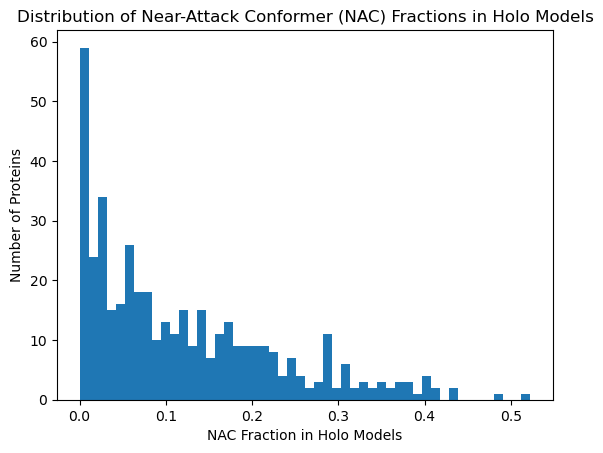

In [49]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

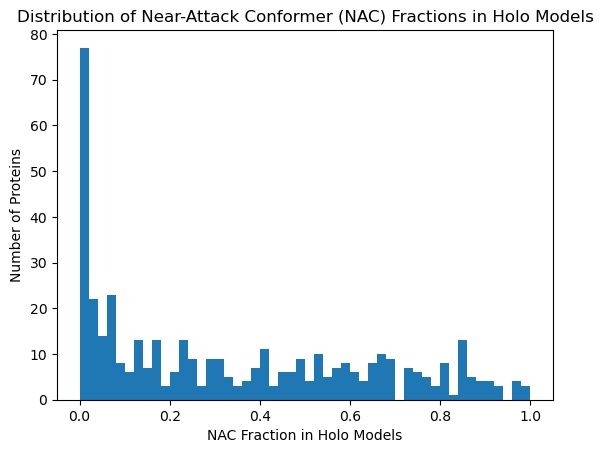

In [50]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_apo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

Split PLACER outputs into the models to satisfy NAC geometry
------------------------------------------------------------------------------

In [54]:
cols = ['entry', 'nac_fraction_holo', 'nac_holo_idxs', 'n_confident_holo',
        'prmsd_mean', 'prmsd_std', 'nac_fraction_apo', 'nac_apo_idxs', 'n_confident_apo']

candidate_df = df_conf[df_conf['entry'].isin(both)].reset_index(drop=True)[cols]

candidate_df.to_csv('results/carA_homologs_nac_candidates_2C.txt', index=False, sep='\t')
candidate_df

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A064CG00,0.411765,2;4;8;11;12;15;16;17;20;21;23;25;28;33,34,2.966543,1.320483,0.68,1;2;3;6;8;9;10;11;12;13;14;15;18;19;21;22;23;2...,100
1,A0A0H3MCY6,0.285714,1;4;9;10;13;15;19;20;30;31;33;37;45;46;52;56,56,2.293562,1.297935,0.78,1;3;4;5;6;7;11;12;13;16;18;20;21;22;23;24;25;2...,100
2,A0A0I9Z3I8,0.304348,2;3;4;10;18;22;25;28;29;32;34;36;39;40,46,2.373432,1.138223,0.96,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;17;18;19;2...,100
3,A0A0U0ZG49,0.400000,4;8;9;10;14;17;19;20;23;26;27;30;34;35,35,2.753320,1.057326,0.75,1;2;3;4;5;6;7;8;9;10;11;12;14;15;16;17;18;19;2...,100
4,A0A0U1E1C0,0.272727,9;11;17;22;29;30;32;33;34;36;37;44;45;46;48,55,2.290655,1.183273,0.60,1;3;4;5;6;8;9;10;12;13;14;15;17;18;21;22;23;24...,100
...,...,...,...,...,...,...,...,...,...
58,A0AB73LM64,0.290909,4;13;18;24;26;30;31;33;37;38;45;46;48;49;53;55,55,2.372084,1.085861,0.82,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;2...,100
59,E5XP76,0.487179,2;3;5;7;9;10;12;13;14;16;19;22;26;27;28;31;32;...,39,2.720116,1.225204,0.85,1;2;3;7;8;9;11;12;13;14;15;16;17;18;19;20;21;2...,100
60,K0EY54,0.400000,2;3;4;7;12;14;20;21;25;26;27;29;31;35,35,2.703234,1.080243,0.94,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
61,V5XIA1,0.311111,3;5;6;10;17;19;21;22;25;32;34;37;40;44,45,2.618986,1.254007,0.61,1;3;4;5;6;7;8;9;10;16;17;18;19;20;21;22;23;24;...,100


In [55]:
import os
from Bio.PDB import PDBIO
from tqdm import tqdm

from process import structure

src_dir = "outputs/placer/carA_holo_adi_amp_homologs_100_2"
dst_dir = "inputs/docking/carA_homologs_2C"
os.makedirs(dst_dir, exist_ok=True)

io = PDBIO()
for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    base_name = row['entry']
    src_path = os.path.join(src_dir, f"{base_name}.relax_model.pdb")

    out_dir = os.path.join(dst_dir, base_name)
    os.makedirs(out_dir, exist_ok=True)

    models = structure.load_models_from_pdb(src_path)
    for idx in row['nac_holo_idxs'].split(';'):
        idx = int(idx)
        io.set_structure(models[int(idx) - 1])   # 1-based -> 0-based
        io.save(os.path.join(out_dir, f"{base_name}.relax_model_{idx}.pdb"))

100%|██████████| 63/63 [01:14<00:00,  1.19s/it]


'2'